In [ ]:
!pip install google-play-scraper pandas

In [ ]:
from google_play_scraper import Sort, reviews
import pandas as pd
import time
import re



APPS = {
    "bKash": "com.bKash.customerapp",
    "Nagad": "com.konasl.nagad",
}

REVIEWS_PER_LOCALE = 10000
BATCH_SIZE = 20



def contains_bangla(text):
    """
    Returns True if the review contains Bengali Unicode characters.
    """
    if not isinstance(text, str):
        return False

    return bool(re.search(r"[\u0980-\u09FF]", text))




def scrape_reviews(app_name, package_id, lang, target_count=5000):

    print(f"\nScraping {app_name}")
    print(f"Locale requested: {lang}")

    all_reviews = []
    continuation_token = None

    while len(all_reviews) < target_count:

        remaining = target_count - len(all_reviews)
        batch_size = min(BATCH_SIZE, remaining)

        try:

            batch, continuation_token = reviews(
                package_id,
                lang=lang,
                country="bd",
                sort=Sort.NEWEST,
                count=batch_size,
                continuation_token=continuation_token
            )

        except Exception as e:
            print(f"Error: {e}")
            break

        if not batch:
            print("No more reviews returned.")
            break

        all_reviews.extend(batch)

        print(
            f"Collected {len(all_reviews)} / "
            f"{target_count} reviews"
        )

        if continuation_token is None:
            break

        time.sleep(1)

    if len(all_reviews) == 0:
        return pd.DataFrame()

    df = pd.DataFrame(all_reviews)

    df["app"] = app_name
    df["package_id"] = package_id
    df["locale_requested"] = lang

    # Check actual text for Bangla characters
    df["contains_bangla"] = df["content"].apply(contains_bangla)

    wanted_columns = [
        "app",
        "package_id",
        "reviewId",
        "userName",
        "content",
        "score",
        "thumbsUpCount",
        "reviewCreatedVersion",
        "at",
        "locale_requested",
        "contains_bangla"
    ]

    # Only select columns that actually exist
    wanted_columns = [
        col for col in wanted_columns
        if col in df.columns
    ]

    return df[wanted_columns]


all_data = []

for app_name, package_id in APPS.items():

    # English locale
    df_en = scrape_reviews(
        app_name,
        package_id,
        lang="en",
        target_count=REVIEWS_PER_LOCALE
    )

    if not df_en.empty:
        all_data.append(df_en)

    # Bangla locale
    df_bn = scrape_reviews(
        app_name,
        package_id,
        lang="bn",
        target_count=REVIEWS_PER_LOCALE
    )

    if not df_bn.empty:
        all_data.append(df_bn)




if len(all_data) == 0:

    print("\nNo reviews were collected.")

else:

    final_df = pd.concat(
        all_data,
        ignore_index=True
    )

    print("\nBefore deduplication:", len(final_df))

    # Same review may appear under both requested locales
    final_df.drop_duplicates(
        subset="reviewId",
        keep="first",
        inplace=True
    )

    print("After deduplication:", len(final_df))

    # Sort newest first
    final_df["at"] = pd.to_datetime(final_df["at"])

    final_df.sort_values(
        by="at",
        ascending=False,
        inplace=True
    )

    # Save
    output_file = "bkash_nagad_reviews.csv"

    final_df.to_csv(
        output_file,
        index=False,
        encoding="utf-8-sig"
    )

    print("\n--------------------------------")
    print("SCRAPING COMPLETE")
    print("--------------------------------")

    print(f"\nSaved to: {output_file}")
    print(f"Total unique reviews: {len(final_df)}")

    print("\nReviews by app:")
    print(final_df["app"].value_counts())

    print("\nReviews containing Bangla script:")
    print(final_df["contains_bangla"].value_counts())

    print("\nApp × Bangla:")
    print(
        pd.crosstab(
            final_df["app"],
            final_df["contains_bangla"]
        )
    )

    print("\nStar distribution:")
    print(
        final_df.groupby(
            ["app", "score"]
        ).size()
    )


Scraping bKash
Locale requested: en
Collected 20 / 10000 reviews
Collected 40 / 10000 reviews
Collected 60 / 10000 reviews
Collected 80 / 10000 reviews
Collected 100 / 10000 reviews
Collected 120 / 10000 reviews
Collected 140 / 10000 reviews
Collected 160 / 10000 reviews
Collected 180 / 10000 reviews
Collected 200 / 10000 reviews
Collected 220 / 10000 reviews
Collected 240 / 10000 reviews
Collected 260 / 10000 reviews
Collected 280 / 10000 reviews
Collected 300 / 10000 reviews
Collected 320 / 10000 reviews
Collected 340 / 10000 reviews
Collected 360 / 10000 reviews
Collected 380 / 10000 reviews
Collected 400 / 10000 reviews
Collected 420 / 10000 reviews
Collected 440 / 10000 reviews
Collected 460 / 10000 reviews
Collected 480 / 10000 reviews
Collected 500 / 10000 reviews
Collected 520 / 10000 reviews
Collected 540 / 10000 reviews
Collected 560 / 10000 reviews
Collected 580 / 10000 reviews
Collected 600 / 10000 reviews
Collected 620 / 10000 reviews
Collected 640 / 10000 reviews
Collect

KeyboardInterrupt: 

In [ ]:
from google.colab import files
files.download("bkash_nagad_reviews.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
!pip install -q google-play-scraper pandas


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.2/50.2 kB 2.3 MB/s eta 0:00:00


In [ ]:
from google_play_scraper import Sort, reviews
import pandas as pd
import time
import re
import random



APPS = {
    "bKash": "com.bKash.customerapp",
    "Nagad": "com.konasl.nagad",
}

# 50,000 × 2 apps × 2 locales = 200,000 target
REVIEWS_PER_APP_LOCALE = 50000

# Google Play supports max ~200 reviews per page
BATCH_SIZE = 200

OUTPUT_FILE = "bkash_nagad_200k_reviews.csv"




def contains_bangla(text):
    if not isinstance(text, str):
        return False

    return bool(re.search(r"[\u0980-\u09FF]", text))




def scrape_app_reviews(
    app_name,
    package_id,
    lang,
    target_count=REVIEWS_PER_APP_LOCALE
):

    print("\n" + "=" * 60)
    print(f"Scraping: {app_name}")
    print(f"Locale: {lang}")
    print(f"Target: {target_count:,}")
    print("=" * 60)

    all_reviews = []
    continuation_token = None

    consecutive_errors = 0
    max_errors = 5

    while len(all_reviews) < target_count:

        remaining = target_count - len(all_reviews)

        request_count = min(
            BATCH_SIZE,
            remaining
        )

        try:

            batch, continuation_token = reviews(
                package_id,
                lang=lang,
                country="bd",
                sort=Sort.NEWEST,
                count=request_count,
                continuation_token=continuation_token
            )

            consecutive_errors = 0

        except Exception as e:

            consecutive_errors += 1

            print(
                f"Error {consecutive_errors}/{max_errors}: {e}"
            )

            if consecutive_errors >= max_errors:
                print("Too many errors. Moving to next dataset.")
                break

            # Wait before retrying
            wait_time = random.randint(10, 20)

            print(f"Waiting {wait_time} seconds...")

            time.sleep(wait_time)

            continue



        if not batch:

            print("Google Play returned no more reviews.")

            break


        all_reviews.extend(batch)


        print(
            f"{app_name} [{lang}] "
            f"→ {len(all_reviews):,} / "
            f"{target_count:,}"
        )



        if continuation_token is None:

            print("No continuation token available.")

            break



        time.sleep(
            random.uniform(1.0, 2.0)
        )




    if len(all_reviews) == 0:

        print(
            f"No reviews collected for "
            f"{app_name} [{lang}]"
        )

        return pd.DataFrame()


    df = pd.DataFrame(all_reviews)


    # Add research variables
    df["app"] = app_name

    df["package_id"] = package_id

    df["locale_requested"] = lang

    df["contains_bangla"] = (
        df["content"]
        .apply(contains_bangla)
    )


    # Columns to keep
    columns = [

        "app",

        "package_id",

        "reviewId",

        "userName",

        "content",

        "score",

        "thumbsUpCount",

        "reviewCreatedVersion",

        "at",

        "locale_requested",

        "contains_bangla"

    ]



    columns = [
        column
        for column in columns
        if column in df.columns
    ]


    df = df[columns]


    print(
        f"\nFinished {app_name} [{lang}]"
    )

    print(
        f"Collected: {len(df):,}"
    )


    return df




all_data = []


for app_name, package_id in APPS.items():



    df_en = scrape_app_reviews(
        app_name,
        package_id,
        lang="en"
    )


    if not df_en.empty:

        all_data.append(df_en)




    df_bn = scrape_app_reviews(
        app_name,
        package_id,
        lang="bn"
    )


    if not df_bn.empty:

        all_data.append(df_bn)





if len(all_data) == 0:

    print("\nNo reviews were collected.")


else:

    final_df = pd.concat(
        all_data,
        ignore_index=True
    )


    print("\n" + "=" * 60)

    print("SCRAPING FINISHED")

    print("=" * 60)


    print(
        f"\nReviews before removing duplicates: "
        f"{len(final_df):,}"
    )




    final_df.drop_duplicates(
        subset="reviewId",
        keep="first",
        inplace=True
    )


    print(
        f"Unique reviews after deduplication: "
        f"{len(final_df):,}"
    )




    final_df = final_df[
        final_df["content"].notna()
    ]

    final_df = final_df[
        final_df["content"]
        .astype(str)
        .str.strip()
        .ne("")
    ]


    print(
        f"Reviews with usable text: "
        f"{len(final_df):,}"
    )




    final_df["at"] = pd.to_datetime(
        final_df["at"],
        errors="coerce"
    )


    final_df.sort_values(
        "at",
        ascending=False,
        inplace=True
    )




    final_df.to_csv(
        OUTPUT_FILE,
        index=False,
        encoding="utf-8-sig"
    )


    print("\n" + "=" * 60)

    print("DATASET SAVED")

    print("=" * 60)


    print(
        f"\nFile name: {OUTPUT_FILE}"
    )

    print(
        f"Final dataset size: "
        f"{len(final_df):,}"
    )




    print("\nREVIEWS BY APP")

    print(
        final_df["app"]
        .value_counts()
    )


    print("\nREVIEWS BY REQUESTED LOCALE")

    print(
        final_df[
            "locale_requested"
        ]
        .value_counts()
    )


    print("\nAPP × LOCALE")

    print(
        pd.crosstab(
            final_df["app"],
            final_df["locale_requested"]
        )
    )


    print("\nBANGLA CHARACTERS")

    print(
        final_df[
            "contains_bangla"
        ]
        .value_counts()
    )


    print("\nSTAR RATINGS")

    print(
        final_df[
            "score"
        ]
        .value_counts()
        .sort_index()
    )


    print("\nDATE RANGE")

    print(
        "Oldest:",
        final_df["at"].min()
    )

    print(
        "Newest:",
        final_df["at"].max()
    )


    print("\nDONE!")


Scraping: bKash
Locale: en
Target: 50,000
bKash [en] → 200 / 50,000
bKash [en] → 400 / 50,000
bKash [en] → 600 / 50,000
bKash [en] → 800 / 50,000
bKash [en] → 1,000 / 50,000
bKash [en] → 1,200 / 50,000
bKash [en] → 1,400 / 50,000
bKash [en] → 1,600 / 50,000
bKash [en] → 1,800 / 50,000
bKash [en] → 2,000 / 50,000
bKash [en] → 2,200 / 50,000
bKash [en] → 2,400 / 50,000
bKash [en] → 2,600 / 50,000
bKash [en] → 2,800 / 50,000
bKash [en] → 3,000 / 50,000
bKash [en] → 3,200 / 50,000
bKash [en] → 3,400 / 50,000
bKash [en] → 3,600 / 50,000
bKash [en] → 3,800 / 50,000
bKash [en] → 4,000 / 50,000
bKash [en] → 4,200 / 50,000
bKash [en] → 4,400 / 50,000
bKash [en] → 4,600 / 50,000
bKash [en] → 4,800 / 50,000
bKash [en] → 5,000 / 50,000
bKash [en] → 5,200 / 50,000
bKash [en] → 5,400 / 50,000
bKash [en] → 5,600 / 50,000
bKash [en] → 5,800 / 50,000
bKash [en] → 6,000 / 50,000
bKash [en] → 6,200 / 50,000
bKash [en] → 6,400 / 50,000
bKash [en] → 6,600 / 50,000
bKash [en] → 6,800 / 50,000
bKash [en] → 

In [ ]:
final_df.to_csv(
    "bkash_nagad_200k_reviews.csv",
    index=False,
    encoding="utf-8-sig"
)

print("Saved successfully!")
print("Total rows:", len(final_df))

Saved successfully!
Total rows: 121013


In [ ]:
from google.colab import files

files.download("bkash_nagad_200k_reviews.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
print(final_df.shape)

(121013, 11)


In [ ]:
!pip install -q pandas==2.2.2
!pip install -q -U transformers sentencepiece accelerate tqdm

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.7/12.7 MB 75.8 MB/s eta 0:00:00


In [ ]:
import pandas as pd
import torch
import transformers

print("Pandas:", pd.__version__)
print("PyTorch:", torch.__version__)
print("Transformers:", transformers.__version__)
print("GPU available:", torch.cuda.is_available())

Pandas: 2.2.2
PyTorch: 2.11.0+cpu
Transformers: 5.14.1
GPU available: False


In [ ]:
!pip install -q pandas==2.2.2
!pip install -q -U transformers sentencepiece accelerate tqdm

In [ ]:
import pandas as pd
import torch
import transformers

print("Pandas:", pd.__version__)
print("PyTorch:", torch.__version__)
print("Transformers:", transformers.__version__)
print("GPU available:", torch.cuda.is_available())

Pandas: 2.2.2
PyTorch: 2.11.0+cpu
Transformers: 5.14.1
GPU available: False


In [ ]:
import pandas as pd

INPUT_FILE = "/content/bkash_nagad_200k_reviews.xlsx"

df = pd.read_excel(INPUT_FILE)

print("Rows:", len(df))
print("Columns:", df.columns.tolist())

Rows: 121013
Columns: ['app', 'package_id', 'reviewId', 'userName', 'content', 'score', 'thumbsUpCount', 'reviewCreatedVersion', 'at', 'locale_requested', 'contains_bangla']


In [ ]:
!nvidia-smi

Sun Aug  9 19:49:01 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   39C    P8              9W /   70W |       3MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [ ]:
import torch

print("PyTorch:", torch.__version__)
print("GPU available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

PyTorch: 2.11.0+cu128
GPU available: True
GPU: Tesla T4


In [ ]:
import pandas as pd
import os

INPUT_FILE = "/content/bkash_nagad_200k_reviews.xlsx"

print("File exists:", os.path.exists(INPUT_FILE))

df = pd.read_excel(INPUT_FILE)

print("Dataset loaded successfully!")
print("Rows:", len(df))
print("Columns:", df.columns.tolist())

File exists: True
Dataset loaded successfully!
Rows: 121013
Columns: ['app', 'package_id', 'reviewId', 'userName', 'content', 'score', 'thumbsUpCount', 'reviewCreatedVersion', 'at', 'locale_requested', 'contains_bangla']


In [ ]:
import pandas as pd
import torch
import re
import unicodedata
import os

from tqdm.auto import tqdm
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM


# ============================================================
# SETTINGS
# ============================================================

INPUT_FILE = "/content/bkash_nagad_200k_reviews.xlsx"

OUTPUT_FILE = "/content/bkash_nagad_cleaned_translated.csv"

CHECKPOINT_FILE = "/content/bkash_nagad_checkpoint.csv"

MODEL_NAME = "facebook/nllb-200-distilled-600M"

BATCH_SIZE = 16
SAVE_EVERY = 1000


# ============================================================
# GPU CHECK
# ============================================================

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Device:", device)

if not torch.cuda.is_available():
    raise RuntimeError(
        "GPU is not active. "
        "Go to Runtime > Change runtime type > T4 GPU."
    )

print("GPU:", torch.cuda.get_device_name(0))


# ============================================================
# LOAD RAW DATA
# ============================================================

print("\nLoading raw dataset...")

df = pd.read_excel(INPUT_FILE)

print("Original rows:", len(df))


# ============================================================
# PRESERVE ORIGINAL REVIEW
# ============================================================

df["original_text"] = df["content"]


# ============================================================
# REMOVE DUPLICATES
# ============================================================

before = len(df)

if "reviewId" in df.columns:

    df = df.drop_duplicates(
        subset="reviewId",
        keep="first"
    )

print(
    "Duplicate reviews removed:",
    before - len(df)
)


# ============================================================
# REMOVE MISSING TEXT
# ============================================================

before = len(df)

df = df[
    df["content"].notna()
].copy()

print(
    "Missing reviews removed:",
    before - len(df)
)


# ============================================================
# CLEANING FUNCTION
# ============================================================

def clean_text(text):

    text = str(text)

    # Unicode normalization
    text = unicodedata.normalize(
        "NFKC",
        text
    )

    # Remove invisible characters
    text = re.sub(
        r"[\u200B-\u200D\uFEFF]",
        "",
        text
    )

    # Remove URLs
    text = re.sub(
        r"https?://\S+|www\.\S+",
        " ",
        text
    )

    # Remove email addresses
    text = re.sub(
        r"\S+@\S+\.\S+",
        " ",
        text
    )

    # Remove HTML
    text = re.sub(
        r"<[^>]+>",
        " ",
        text
    )

    # Reduce repeated punctuation
    text = re.sub(
        r"([!?.,])\1{2,}",
        r"\1",
        text
    )

    # Normalize spaces
    text = re.sub(
        r"\s+",
        " ",
        text
    )

    return text.strip()


df["cleaned_text"] = (
    df["content"]
    .apply(clean_text)
)


# ============================================================
# REMOVE EMPTY REVIEWS AFTER CLEANING
# ============================================================

before = len(df)

df = df[
    df["cleaned_text"].str.len() > 0
].copy()

print(
    "Empty reviews removed:",
    before - len(df)
)


# ============================================================
# SCRIPT DETECTION
# ============================================================

def has_bangla(text):

    return bool(
        re.search(
            r"[\u0980-\u09FF]",
            str(text)
        )
    )


def has_latin(text):

    return bool(
        re.search(
            r"[A-Za-z]",
            str(text)
        )
    )


def script_group(text):

    bn = has_bangla(text)
    latin = has_latin(text)

    if bn and latin:
        return "Bangla-English Mixed"

    elif bn:
        return "Bangla"

    elif latin:
        return "Latin Script"

    else:
        return "Other"


df["has_bangla_script"] = (
    df["cleaned_text"]
    .apply(has_bangla)
)

df["script_group"] = (
    df["cleaned_text"]
    .apply(script_group)
)


print("\nScript distribution:")

print(
    df["script_group"]
    .value_counts()
)


# ============================================================
# LENGTH VARIABLES
# ============================================================

df["word_count"] = (
    df["cleaned_text"]
    .str.split()
    .str.len()
)

df["character_count"] = (
    df["cleaned_text"]
    .str.len()
)


# ============================================================
# FIX SCORE / DATE
# ============================================================

if "score" in df.columns:

    df["score"] = pd.to_numeric(
        df["score"],
        errors="coerce"
    )


if "thumbsUpCount" in df.columns:

    df["thumbsUpCount"] = pd.to_numeric(
        df["thumbsUpCount"],
        errors="coerce"
    )


if "at" in df.columns:

    df["at"] = pd.to_datetime(
        df["at"],
        errors="coerce"
    )


# ============================================================
# CREATE TRANSLATION COLUMN
# ============================================================

df["english_translation"] = pd.NA


# Non-Bangla-script reviews:
# keep cleaned text as-is for now
mask_non_bn = (
    df["has_bangla_script"] == False
)

df.loc[
    mask_non_bn,
    "english_translation"
] = df.loc[
    mask_non_bn,
    "cleaned_text"
]


# ============================================================
# LOAD TRANSLATION MODEL
# ============================================================

print("\nLoading NLLB model...")

tokenizer = AutoTokenizer.from_pretrained(
    MODEL_NAME,
    src_lang="ben_Beng"
)

model = AutoModelForSeq2SeqLM.from_pretrained(
    MODEL_NAME
)

model = model.to(device)

model.eval()

model = model.half()

ENGLISH_ID = tokenizer.convert_tokens_to_ids(
    "eng_Latn"
)

print("Model loaded.")


# ============================================================
# TRANSLATION FUNCTION
# ============================================================

def translate_batch(texts):

    inputs = tokenizer(
        [str(x) for x in texts],
        return_tensors="pt",
        padding=True,
        truncation=True,
        max_length=256
    )

    inputs = {
        k: v.to(device)
        for k, v in inputs.items()
    }

    with torch.inference_mode():

        generated = model.generate(
            **inputs,
            forced_bos_token_id=ENGLISH_ID,
            max_length=256,
            num_beams=1
        )

    return tokenizer.batch_decode(
        generated,
        skip_special_tokens=True
    )


# ============================================================
# TRANSLATE BANGLA / MIXED REVIEWS
# ============================================================

indices = df.index[
    df["has_bangla_script"] == True
].tolist()

print(
    "\nReviews to translate:",
    len(indices)
)


translated_since_save = 0


for start in tqdm(
    range(0, len(indices), BATCH_SIZE),
    desc="Cleaning + Bangla → English"
):

    batch_indices = indices[
        start:start + BATCH_SIZE
    ]

    texts = df.loc[
        batch_indices,
        "cleaned_text"
    ].tolist()

    try:

        translations = translate_batch(
            texts
        )

    except torch.cuda.OutOfMemoryError:

        print("\nGPU memory full.")
        print("Saving progress...")

        df.to_csv(
            CHECKPOINT_FILE,
            index=False,
            encoding="utf-8-sig"
        )

        torch.cuda.empty_cache()

        raise RuntimeError(
            "Change BATCH_SIZE from 16 to 8 and rerun."
        )

    df.loc[
        batch_indices,
        "english_translation"
    ] = translations

    translated_since_save += len(
        batch_indices
    )

    if translated_since_save >= SAVE_EVERY:

        df.to_csv(
            CHECKPOINT_FILE,
            index=False,
            encoding="utf-8-sig"
        )

        print("\nCheckpoint saved.")

        translated_since_save = 0


# ============================================================
# FINAL CLEANING OF ENGLISH COLUMN
# ============================================================

df["cleaned_english"] = (
    df["english_translation"]
    .fillna("")
    .apply(clean_text)
)


# ============================================================
# RESET INDEX
# ============================================================

df = df.reset_index(
    drop=True
)


# ============================================================
# SAVE FINAL FILE
# ============================================================

df.to_csv(
    OUTPUT_FILE,
    index=False,
    encoding="utf-8-sig"
)


print("\n==================================")
print("CLEANING + TRANSLATION COMPLETE")
print("==================================")

print("Final rows:", len(df))

print(
    "Bangla-script reviews:",
    df["has_bangla_script"].sum()
)

print(
    "Missing translations:",
    df["english_translation"]
    .isna()
    .sum()
)

print(
    "\nSaved as:",
    OUTPUT_FILE
)

Device: cuda
GPU: Tesla T4

Loading raw dataset...
Original rows: 121013
Duplicate reviews removed: 0
Missing reviews removed: 7
Empty reviews removed: 0

Script distribution:
script_group
Latin Script            92880
Bangla                  23104
Other                    3338
Bangla-English Mixed     1684
Name: count, dtype: int64

Loading NLLB model...


config.json:   0%|          | 0.00/846 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/564 [00:00<?, ?B/s]

sentencepiece.bpe.model: reconstructing file:   0%|          |  0.00B / 4.85MB            

sentencepiece.bpe.model: downloading bytes:           |  0.00B            

...

model.safetensors: downloading bytes:           |  0.00B            

generation_config.json:   0%|          | 0.00/189 [00:00<?, ?B/s]

Model loaded.

Reviews to translate: 24788


Cleaning + Bangla → English:   0%|          | 0/1550 [00:00<?, ?it/s]


Checkpoint saved.

Checkpoint saved.

Checkpoint saved.

Checkpoint saved.

Checkpoint saved.

Checkpoint saved.

Checkpoint saved.

Checkpoint saved.

Checkpoint saved.

Checkpoint saved.

Checkpoint saved.

Checkpoint saved.

Checkpoint saved.

Checkpoint saved.

Checkpoint saved.

Checkpoint saved.

Checkpoint saved.

Checkpoint saved.

Checkpoint saved.

Checkpoint saved.

Checkpoint saved.

Checkpoint saved.

Checkpoint saved.

Checkpoint saved.

CLEANING + TRANSLATION COMPLETE
Final rows: 121006
Bangla-script reviews: 24788
Missing translations: 0

Saved as: /content/bkash_nagad_cleaned_translated.csv


In [ ]:
df[
    df["has_bangla_script"] == True
][
    [
        "original_text",
        "cleaned_text",
        "english_translation",
        "score"
    ]
].sample(20)

,original_text,cleaned_text,english_translation,score
16985,পিন নগদের,পিন নগদের,Pin city,2
119474,ভালো,ভালো,Good.,4
20601,াসহি,াসহি,I'm going to be a good friend.,5
17087,ভালো,ভালো,Good.,5
53157,"বেশি বেশি আমার নগদ ব্যবহার করি,,,,আমি নগদের এক...","বেশি বেশি আমার নগদ ব্যবহার করি,আমি নগদের এক জন...","I use my cash more, I'm lucky to be a regular ...",5
2886,ভালো,ভালো,Good.,5
111537,আমার কাছে ভালো লেগেছে,আমার কাছে ভালো লেগেছে,I like it.,5
77921,হাবিব,হাবিব,Habib,5
776,আমি এফটি আপডেট করতে চাচ্ছি,আমি এফটি আপডেট করতে চাচ্ছি,I'm trying to update the FT.,5
111383,"""বিকাশ"" ডিজিটাল মোবাইল ব্যাংকিংয়ের সবচেয়ে জনপ্...","""বিকাশ"" ডিজিটাল মোবাইল ব্যাংকিংয়ের সবচেয়ে জন...","""Development"" is one of the most popular and w...",5


In [ ]:
from google.colab import files

files.download(
    "/content/bkash_nagad_cleaned_translated.csv"
)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import pandas as pd

df = pd.read_csv(
    "/content/bkash_nagad_200k_reviews.csv",
    low_memory=False
)

print(df.shape)
df.head()

(121013, 11)


,app,package_id,reviewId,userName,content,score,thumbsUpCount,reviewCreatedVersion,at,locale_requested,contains_bangla
0,bKash,com.bKash.customerapp,38c6194d-ccb8-46dd-979f-1a12eb4ea0b8,Md Hossain,nic,1,0,7.3.0,8/8/2026 15:29,en,False
1,bKash,com.bKash.customerapp,6539312f-c774-49bd-bdb5-fe4fd2714301,Fazlul Haque,I have problem with the gambling alert banner....,1,0,7.3.0,8/8/2026 15:22,en,False
2,bKash,com.bKash.customerapp,b2d8a793-5e39-4440-8cc3-6c7bb906b917,gamesum glitch,Make bkash a payment method for play store.It ...,1,0,6.9.5,8/8/2026 15:13,en,False
3,bKash,com.bKash.customerapp,5582a23a-41c0-4076-bd5e-124583b4b9cb,রহমাতুল্লাহ ইসলাম,নাইছ,5,0,NaN,8/8/2026 15:12,en,True
4,Nagad,com.konasl.nagad,7b776b82-6663-474f-a625-5b63d99891ef,Md Khan,nicenice,5,0,1.1.118.03,8/8/2026 15:05,en,False


In [ ]:
import re
import unicodedata

clean_df = df.copy()

print("Original rows:", len(clean_df))

# Remove duplicate review IDs
clean_df = clean_df.drop_duplicates(
    subset="reviewId",
    keep="first"
)

# Remove rows without review text
clean_df = clean_df[
    clean_df["content"].notna()
].copy()

# Preserve original text
clean_df["original_text"] = clean_df["content"]


def clean_text(text):
    text = str(text)

    # Unicode normalization
    text = unicodedata.normalize("NFKC", text)

    # Remove invisible characters
    text = re.sub(r"[\u200B-\u200D\uFEFF]", "", text)

    # Remove URLs
    text = re.sub(r"https?://\S+|www\.\S+", " ", text)

    # Remove email addresses
    text = re.sub(r"\S+@\S+\.\S+", " ", text)

    # Remove HTML tags
    text = re.sub(r"<[^>]+>", " ", text)

    # Normalize repeated spaces
    text = re.sub(r"\s+", " ", text)

    return text.strip()


clean_df["cleaned_text"] = clean_df["content"].apply(clean_text)

# Remove anything that became empty
clean_df = clean_df[
    clean_df["cleaned_text"].str.len() > 0
].copy()

clean_df.reset_index(drop=True, inplace=True)

print("Rows after cleaning:", len(clean_df))

Original rows: 121013
Rows after cleaning: 121011


In [ ]:
clean_df.to_csv(
    "/content/bkash_nagad_cleaned.csv",
    index=False,
    encoding="utf-8-sig"
)

In [ ]:
#BASIC DATASET INFORMATION
print("Dataset shape:")
print(clean_df.shape)

print("\nColumns:")
print(clean_df.columns.tolist())

print("\nData types:")
print(clean_df.dtypes)

Dataset shape:
(121011, 13)

Columns:
['app', 'package_id', 'reviewId', 'userName', 'content', 'score', 'thumbsUpCount', 'reviewCreatedVersion', 'at', 'locale_requested', 'contains_bangla', 'original_text', 'cleaned_text']

Data types:
app                     object
package_id              object
reviewId                object
userName                object
content                 object
score                    int64
thumbsUpCount            int64
reviewCreatedVersion    object
at                      object
locale_requested        object
contains_bangla           bool
original_text           object
cleaned_text            object
dtype: object


In [ ]:
#Missing Values
missing = clean_df.isnull().sum().sort_values(ascending=False)

print(missing)

reviewCreatedVersion    35662
package_id                  0
reviewId                    0
userName                    0
app                         0
content                     0
score                       0
thumbsUpCount               0
at                          0
locale_requested            0
contains_bangla             0
original_text               0
cleaned_text                0
dtype: int64


In [ ]:
missing_percent = (
    clean_df.isnull().mean() * 100
).sort_values(ascending=False)

print(missing_percent)

reviewCreatedVersion    29.470048
package_id               0.000000
reviewId                 0.000000
userName                 0.000000
app                      0.000000
content                  0.000000
score                    0.000000
thumbsUpCount            0.000000
at                       0.000000
locale_requested         0.000000
contains_bangla          0.000000
original_text            0.000000
cleaned_text             0.000000
dtype: float64


In [ ]:
#Duplicate Check
print(
    "Duplicate review IDs:",
    clean_df["reviewId"].duplicated().sum()
)

Duplicate review IDs: 0


In [ ]:
#Number of reviews (Bkash and Nagad)
print(clean_df["app"].value_counts())

print(
    clean_df["app"].value_counts(
        normalize=True
    ) * 100
)

app
bKash    64219
Nagad    56792
Name: count, dtype: int64
app
bKash    53.068729
Nagad    46.931271
Name: proportion, dtype: float64


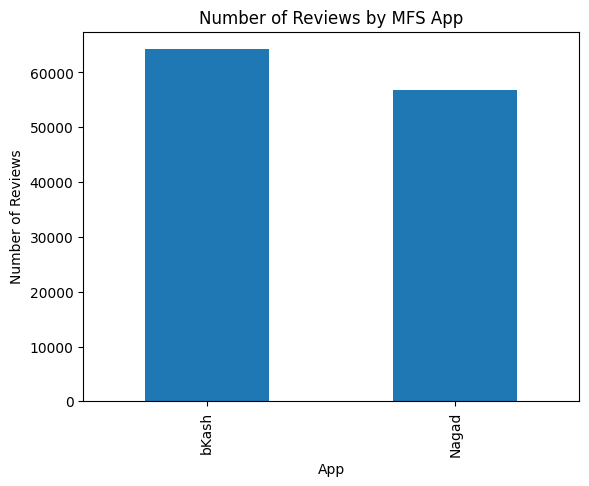

In [ ]:
import matplotlib.pyplot as plt

clean_df["app"].value_counts().plot(
    kind="bar"
)

plt.title("Number of Reviews by MFS App")
plt.xlabel("App")
plt.ylabel("Number of Reviews")
plt.show()

In [ ]:
#Star Rating Distribution
print(
    clean_df["score"]
    .value_counts()
    .sort_index()
)

score
1    15573
2     2842
3     3821
4     5966
5    92809
Name: count, dtype: int64


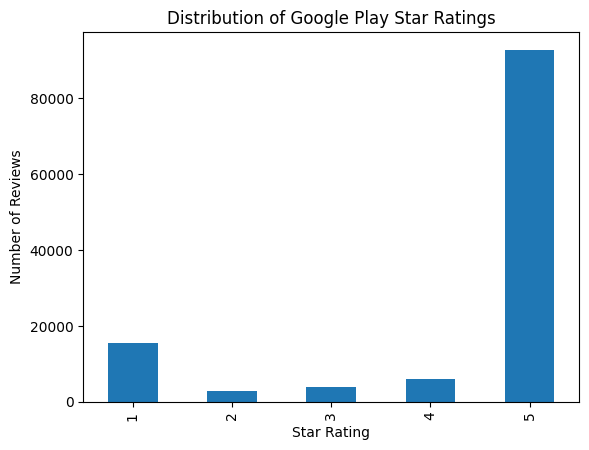

In [ ]:
clean_df["score"].value_counts().sort_index().plot(
    kind="bar"
)

plt.title("Distribution of Google Play Star Ratings")
plt.xlabel("Star Rating")
plt.ylabel("Number of Reviews")
plt.show()

app    Nagad  bKash
score              
1       8520   7053
2       1252   1590
3       1645   2176
4       2511   3455
5      42864  49945


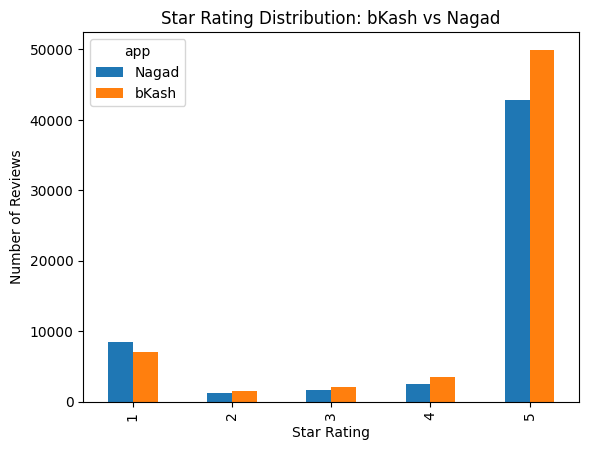

In [ ]:
rating_app = pd.crosstab(
    clean_df["score"],
    clean_df["app"]
)

print(rating_app)

rating_app.plot(
    kind="bar"
)

plt.title("Star Rating Distribution: bKash vs Nagad")
plt.xlabel("Star Rating")
plt.ylabel("Number of Reviews")
plt.show()

In [ ]:
#Data Range
clean_df["at"] = pd.to_datetime(
    clean_df["at"],
    errors="coerce"
)

print(
    "Oldest review:",
    clean_df["at"].min()
)

print(
    "Newest review:",
    clean_df["at"].max()
)

Oldest review: 2018-04-25 10:34:00
Newest review: 2026-08-08 15:29:00


In [ ]:
#Review Length
clean_df["word_count"] = (
    clean_df["cleaned_text"]
    .str.split()
    .str.len()
)

clean_df["character_count"] = (
    clean_df["cleaned_text"]
    .str.len()
)

In [ ]:
print(
    clean_df[
        ["word_count", "character_count"]
    ].describe()
)

          word_count  character_count
count  121011.000000    121011.000000
mean        4.187718        21.805464
std         8.635217        49.008920
min         1.000000         1.000000
25%         1.000000         4.000000
50%         2.000000         8.000000
75%         3.000000        16.000000
max       131.000000       513.000000


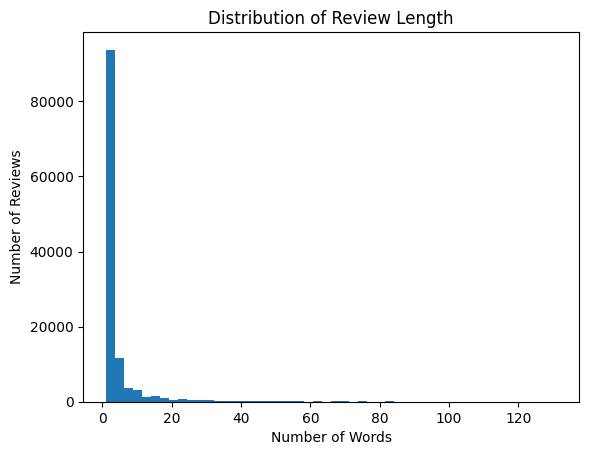

In [ ]:
plt.hist(
    clean_df["word_count"],
    bins=50
)

plt.title("Distribution of Review Length")
plt.xlabel("Number of Words")
plt.ylabel("Number of Reviews")

plt.show()

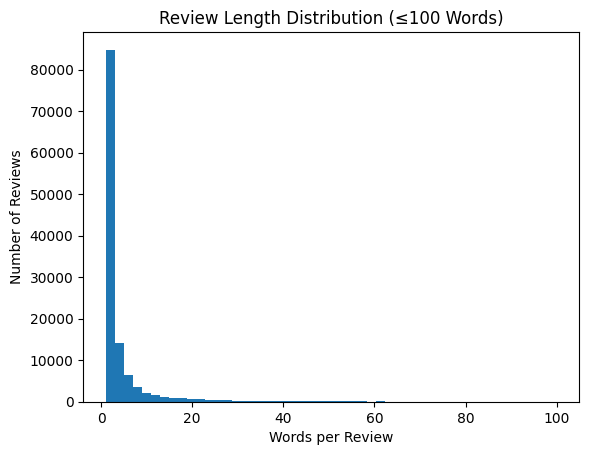

In [ ]:
plt.hist(
    clean_df[
        clean_df["word_count"] <= 100
    ]["word_count"],
    bins=50
)

plt.title("Review Length Distribution (≤100 Words)")
plt.xlabel("Words per Review")
plt.ylabel("Number of Reviews")

plt.show()

In [ ]:
def has_bangla(text):
    return bool(
        re.search(
            r"[\u0980-\u09FF]",
            str(text)
        )
    )


def has_latin(text):
    return bool(
        re.search(
            r"[A-Za-z]",
            str(text)
        )
    )


def script_group(text):

    bn = has_bangla(text)
    latin = has_latin(text)

    if bn and latin:
        return "Bangla-English Mixed"

    elif bn:
        return "Bangla"

    elif latin:
        return "Latin Script"

    else:
        return "Other"


clean_df["script_group"] = (
    clean_df["cleaned_text"]
    .apply(script_group)
)

In [ ]:
print(
    clean_df["script_group"]
    .value_counts()
)

print(
    clean_df["script_group"]
    .value_counts(normalize=True) * 100
)

script_group
Latin Script            92886
Bangla                  23104
Other                    3338
Bangla-English Mixed     1683
Name: count, dtype: int64
script_group
Latin Script            76.758311
Bangla                  19.092479
Other                    2.758427
Bangla-English Mixed     1.390783
Name: proportion, dtype: float64


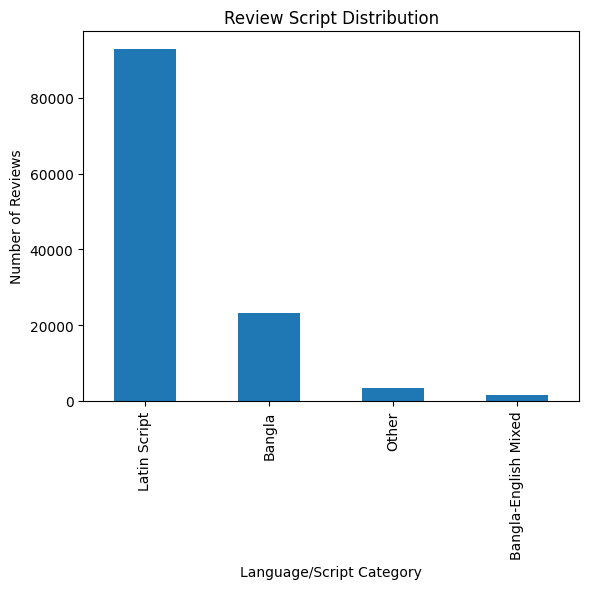

In [ ]:
clean_df[
    "script_group"
].value_counts().plot(
    kind="bar"
)

plt.title("Review Script Distribution")
plt.xlabel("Language/Script Category")
plt.ylabel("Number of Reviews")

plt.show()

In [ ]:
language_app = pd.crosstab(
    clean_df["app"],
    clean_df["script_group"]
)

print(language_app)

script_group  Bangla  Bangla-English Mixed  Latin Script  Other
app                                                            
Nagad          10453                   741         44072   1526
bKash          12651                   942         48814   1812


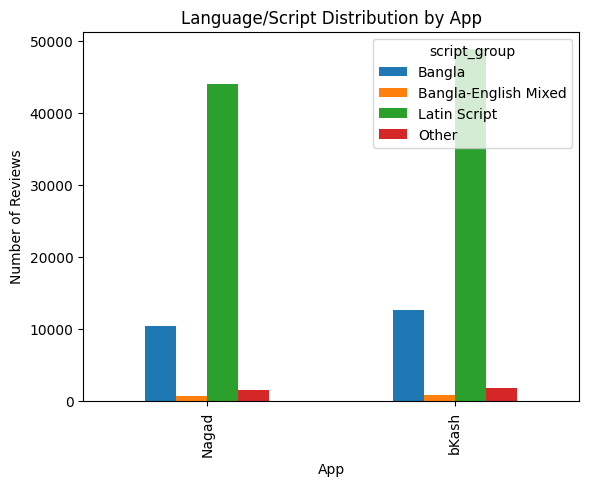

In [ ]:
language_app.plot(
    kind="bar"
)

plt.title("Language/Script Distribution by App")
plt.xlabel("App")
plt.ylabel("Number of Reviews")

plt.show()

In [ ]:
print(
    clean_df["thumbsUpCount"]
    .describe()
)

count    121011.000000
mean          2.172241
std         108.544282
min           0.000000
25%           0.000000
50%           0.000000
75%           0.000000
max       29092.000000
Name: thumbsUpCount, dtype: float64


In [ ]:
#MOST USEFUL REVIEW (IMPORTANT###)

clean_df[
    [
        "app",
        "cleaned_text",
        "score",
        "thumbsUpCount"
    ]
].sort_values(
    "thumbsUpCount",
    ascending=False
).head(20)

,app,cleaned_text,score,thumbsUpCount
101010,Nagad,"It takes a lot of time to log in, besides it s...",1,29092
40594,bKash,I am unable to access my linked bank account. ...,1,19929
77519,bKash,This app simplifies financial transactions lik...,5,7142
68101,Nagad,"No matter where we live, in the village or in ...",5,3950
31488,bKash,I use bKash regularly and find it very conveni...,5,3862
100851,Nagad,Clean UI. Much cleaner and lighter than Bkash ...,5,3261
65998,Nagad,It would be better if you decrease the send mo...,5,2782
34511,Nagad,"Great app, but I would love to see a ""Favorite...",5,2715
26886,Nagad,Nagad has made digital transactions faster and...,5,2468
74335,bKash,So disappointed with this update. I'm not bein...,1,2396


In [ ]:
clean_df[
    [
        "app",
        "cleaned_text",
        "score",
        "thumbsUpCount"
    ]
].sort_values(
    "thumbsUpCount",
    ascending=False
).head(1000)

,app,cleaned_text,score,thumbsUpCount
101010,Nagad,"It takes a lot of time to log in, besides it s...",1,29092
40594,bKash,I am unable to access my linked bank account. ...,1,19929
77519,bKash,This app simplifies financial transactions lik...,5,7142
68101,Nagad,"No matter where we live, in the village or in ...",5,3950
31488,bKash,I use bKash regularly and find it very conveni...,5,3862
...,...,...,...,...
27004,bKash,bKash Service is not good abroad can't login a...,1,29
48705,bKash,I am depressed about new update. my device Tec...,1,29
114108,bKash,আমি পেটেক মাসে 3000 টাকা লেনদেন করি কিন্তু। কো...,1,29
120485,bKash,this is very usefull app,5,29


In [ ]:
useful_reviews = clean_df[
    [
        "app",
        "cleaned_text",
        "score",
        "thumbsUpCount"
    ]
].sort_values(
    "thumbsUpCount",
    ascending=False
)

useful_reviews

,app,cleaned_text,score,thumbsUpCount
101010,Nagad,"It takes a lot of time to log in, besides it s...",1,29092
40594,bKash,I am unable to access my linked bank account. ...,1,19929
77519,bKash,This app simplifies financial transactions lik...,5,7142
68101,Nagad,"No matter where we live, in the village or in ...",5,3950
31488,bKash,I use bKash regularly and find it very conveni...,5,3862
...,...,...,...,...
44503,bKash,nice moment,5,0
44502,Nagad,fabulous,5,0
44501,bKash,fabulous,5,0
44500,bKash,very good experience,5,0


In [ ]:
# Make a copy for cleaning
clean_df = df.copy()

# Remove duplicate review IDs
clean_df = clean_df.drop_duplicates(subset="reviewId")

# Remove missing review text
clean_df = clean_df.dropna(subset=["content"])

# Basic text cleaning
def clean_text(text):
    text = str(text)
    text = unicodedata.normalize("NFKC", text)
    text = re.sub(r'[\u200b-\u200d\ufeff]', '', text)
    text = re.sub(r'http\S+|www\.\S+', '', text)
    text = re.sub(r'\S+@\S+', '', text)
    text = re.sub(r'<.*?>', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

clean_df["cleaned_text"] = clean_df["content"].apply(clean_text)

# Remove empty reviews
clean_df = clean_df[
    clean_df["cleaned_text"].str.strip() != ""
].copy()

# Make sure rating and date are correct types
clean_df["score"] = pd.to_numeric(
    clean_df["score"],
    errors="coerce"
)

clean_df["at"] = pd.to_datetime(
    clean_df["at"],
    errors="coerce"
)

print("Clean dataset ready!")
print("Rows:", len(clean_df))

Clean dataset ready!
Rows: 121011


In [ ]:
clean_df[
    ["app", "cleaned_text", "score", "at"]
].head()

,app,cleaned_text,score,at
0,bKash,nic,1,2026-08-08 15:29:00
1,bKash,I have problem with the gambling alert banner....,1,2026-08-08 15:22:00
2,bKash,Make bkash a payment method for play store.It ...,1,2026-08-08 15:13:00
3,bKash,নাইছ,5,2026-08-08 15:12:00
4,Nagad,nicenice,5,2026-08-08 15:05:00


In [ ]:
year_df = clean_df.copy()

In [ ]:
import pandas as pd
import re


year_df = clean_df.copy()

year_df["at"] = pd.to_datetime(
    year_df["at"],
    errors="coerce"
)

year_df["year"] = year_df["at"].dt.year

# Use cleaned text
TEXT_COLUMN = "cleaned_text"

# Negative reviews = 1 or 2 stars
negative_df = year_df[
    year_df["score"].isin([1, 2])
].copy()




complaint_categories = {

    "Login / OTP / Verification": [
        "login", "log in", "otp",
        "verification", "verification code",
        "pin", "sign in",
        "লগইন", "ওটিপি", "ভেরিফিকেশন",
        "কোড", "পিন"
    ],

    "App Performance / Server": [
        "slow", "lag", "laggy",
        "crash", "freeze", "loading",
        "server", "timeout",
        "not responding",
        "স্লো", "সার্ভার",
        "লোডিং", "হ্যাং", "ক্র্যাশ",
        "কাজ করছে না", "ওপেন হয় না"
    ],

    "Update / Device Compatibility": [
        "update", "upgrade",
        "android", "device",
        "not support", "not supporting",
        "compatibility",
        "আপডেট", "আপগ্রেড",
        "সাপোর্ট করে না",
        "মোবাইলে"
    ],

    "Transaction / Payment Failure": [
        "transaction", "send money",
        "cash out", "cashout",
        "recharge", "payment",
        "bill", "pending",
        "failed", "deducted",
        "refund", "reversal",
        "লেনদেন", "টাকা",
        "রিচার্জ", "পেমেন্ট",
        "বিল", "ক্যাশ আউট",
        "পেন্ডিং", "ফেরত"
    ],

    "Customer Support": [
        "customer service",
        "customer care",
        "helpline", "hotline",
        "support", "agent",
        "call", "chat",
        "কাস্টমার সার্ভিস",
        "কাস্টমার কেয়ার",
        "হেল্পলাইন",
        "হটলাইন"
    ],

    "Fees / Charges": [
        "fee", "fees",
        "charge", "charges",
        "cost", "expensive",
        "খরচ", "চার্জ", "ফি"
    ],

    "KYC / Account Verification": [
        "kyc", "nid",
        "national id",
        "photo", "signature",
        "account verification",
        "এনআইডি", "ছবি",
        "স্বাক্ষর"
    ],

    "Security / Privacy": [
        "security", "privacy",
        "permission", "microphone",
        "camera", "contacts",
        "unauthorized", "fraud",
        "scam",
        "নিরাপত্তা", "গোপনতা",
        "পারমিশন", "ক্যামেরা"
    ],

    "Notifications / Ads": [
        "notification",
        "notifications",
        "advertisement",
        "ads", "promotion",
        "promotional", "offer",
        "নোটিফিকেশন",
        "বিজ্ঞাপন", "অফার"
    ],

    "SIM / eSIM Problems": [
        "sim slot",
        "slot 1", "slot 2",
        "sim 1", "esim", "e-sim",
        "registered sim",
        "সিম স্লট", "সিম ১"
    ]
}




for category, keywords in complaint_categories.items():

    pattern = "|".join(
        re.escape(word)
        for word in keywords
    )

    negative_df[category] = (
        negative_df[TEXT_COLUMN]
        .fillna("")
        .astype(str)
        .str.contains(
            pattern,
            case=False,
            regex=True
        )
    )




print("TOTAL REVIEWS BY YEAR AND APP")
print(
    year_df[
        year_df["year"].isin([2018, 2025])
    ]
    .groupby(["year", "app"])
    .size()
)

print("\nNEGATIVE REVIEWS BY YEAR AND APP")
print(
    negative_df[
        negative_df["year"].isin([2018, 2025])
    ]
    .groupby(["year", "app"])
    .size()
)



results = []

for app in ["bKash", "Nagad"]:

    for year in [2018, 2025]:

        subset = negative_df[
            (negative_df["app"] == app) &
            (negative_df["year"] == year)
        ]

        total_negative = len(subset)

        for category in complaint_categories.keys():

            count = subset[category].sum()

            percentage = (
                count / total_negative * 100
                if total_negative > 0
                else 0
            )

            results.append({
                "App": app,
                "Year": year,
                "Complaint": category,
                "Count": int(count),
                "Percent_of_Negative_Reviews":
                    round(percentage, 2)
            })


complaint_comparison = pd.DataFrame(results)




complaint_comparison.sort_values(
    ["App", "Year", "Count"],
    ascending=[True, True, False]
)

TOTAL REVIEWS BY YEAR AND APP
year  app  
2018  Nagad        4
      bKash      304
2025  Nagad    21602
      bKash    25234
dtype: int64

NEGATIVE REVIEWS BY YEAR AND APP
year  app  
2018  bKash      56
2025  Nagad    4320
      bKash    3490
dtype: int64


,App,Year,Complaint,Count,Percent_of_Negative_Reviews
20,Nagad,2018,Login / OTP / Verification,0,0.00
21,Nagad,2018,App Performance / Server,0,0.00
22,Nagad,2018,Update / Device Compatibility,0,0.00
23,Nagad,2018,Transaction / Payment Failure,0,0.00
24,Nagad,2018,Customer Support,0,0.00
25,Nagad,2018,Fees / Charges,0,0.00
26,Nagad,2018,KYC / Account Verification,0,0.00
27,Nagad,2018,Security / Privacy,0,0.00
28,Nagad,2018,Notifications / Ads,0,0.00
29,Nagad,2018,SIM / eSIM Problems,0,0.00


In [ ]:
def show_complaints(app, year, category, n=20):

    data = negative_df[
        (negative_df["app"] == app) &
        (negative_df["year"] == year) &
        (negative_df[category] == True)
    ]

    return data[
        [
            "app",
            "year",
            "cleaned_text",
            "score",
            "thumbsUpCount"
        ]
    ].sort_values(
        "thumbsUpCount",
        ascending=False
    ).head(n)

In [ ]:
show_complaints(
    "bKash",
    2018,
    "Update / Device Compatibility",
    30
)

,app,year,cleaned_text,score,thumbsUpCount
120746,bKash,2018,কাল আপগ্রেড করলাম কিন্তু এখন আর এপস সাপোর্ট কর...,1,27
120804,bKash,2018,"শুনেছি ভাল এ্যাপস,,, কিন্তু আমার মোবাইলে কাজ ক...",1,27
120722,bKash,2018,বিকাশ অ্যাপ ওপেন করলাম। আপডেট চাইলো দিলাম।এরপর...,1,9
120713,bKash,2018,update korar por open hoi na,1,7
120969,bKash,2018,Not supporting my phone ANDRD VER 7.1.2,1,6
120766,bKash,2018,Walton primo nf2+ হ্যান্ডসেটে সাপোর্ট করে না,1,3
120927,bKash,2018,"বিকাশ একাউন্ট খুজলেছি, মোবাইলে টাক রিচাচ করার ...",2,3
120710,bKash,2018,"ওপেন হয় না , আমার মোবাইলে",1,2
120712,bKash,2018,ভাই আগে বিকাশ এপস কাজ করতো এখন আপডেট করার পর আ...,1,2
120997,bKash,2018,not supported on Android 4.4.4 please resolved...,2,1


In [ ]:
show_complaints(
    "bKash",
    2025,
    "Update / Device Compatibility",
    30
)

,app,year,cleaned_text,score,thumbsUpCount
51355,bKash,2025,Your app freezes after update. You should neve...,1,650
24675,bKash,2025,The app keeps crashing on my Android 10 (Tecno...,1,527
65926,bKash,2025,This update is so disappointed. Since the upda...,1,425
51886,bKash,2025,So disappointed with this update. I'm not bein...,1,365
47582,bKash,2025,"Well, it works, but the UI/UX need serious imp...",2,281
61763,bKash,2025,"মাত্র একটি ষ্টার দিলাম, কারণ মালয়েশিয়ায় বিক...",1,233
40785,bKash,2025,"Can't login, OTP doesn't come within 30 second...",1,227
24967,bKash,2025,The new *Update* broke more things than it fix...,1,212
38530,bKash,2025,"After a few days, this app does not open on my...",1,166
23967,bKash,2025,প্রতি মাসে আপডেট দেওয়া লাগে কেন,1,151


In [ ]:
show_complaints(
    "Nagad",
    2025,
    "Login / OTP / Verification",
    30
)

,app,year,cleaned_text,score,thumbsUpCount
53771,Nagad,2025,Such a stupid service. It won’t let you make t...,1,402
51968,Nagad,2025,. Login & OTP Problems Many users face difficu...,1,349
63725,Nagad,2025,Very very very very very bad. If your nagad ap...,1,329
47340,Nagad,2025,It's a really disgusting experience when i try...,2,279
54819,Nagad,2025,I think this is one of the worst app ever. Whe...,1,238
62272,Nagad,2025,My experience with Nagad is very bad. I have s...,1,181
21329,Nagad,2025,I can't log into my account when the OTP come ...,1,164
32831,Nagad,2025,"I installed the app many times, but when I get...",1,163
53635,Nagad,2025,Nagad is a terrible app. When trying to log in...,1,159
26027,Nagad,2025,What kind of thing is bothering me now? There ...,1,158


In [ ]:
import pandas as pd
import re
import unicodedata

INPUT_FILE = "/content/bkash_nagad_200k_reviews.csv"

df = pd.read_csv(INPUT_FILE, low_memory=False)

print("Dataset loaded!")
print("Rows:", len(df))
print("Columns:", df.columns.tolist())

Dataset loaded!
Rows: 121013
Columns: ['app', 'package_id', 'reviewId', 'userName', 'content', 'score', 'thumbsUpCount', 'reviewCreatedVersion', 'at', 'locale_requested', 'contains_bangla']


In [ ]:
clean_df = df.copy()

# Remove duplicate review IDs
clean_df = clean_df.drop_duplicates(subset="reviewId")

# Remove missing reviews
clean_df = clean_df.dropna(subset=["content"])

def clean_text(text):
    text = str(text)
    text = unicodedata.normalize("NFKC", text)
    text = re.sub(r'[\u200b-\u200d\ufeff]', '', text)
    text = re.sub(r'http\S+|www\.\S+', '', text)
    text = re.sub(r'\S+@\S+', '', text)
    text = re.sub(r'<.*?>', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

clean_df["cleaned_text"] = clean_df["content"].apply(clean_text)

clean_df = clean_df[
    clean_df["cleaned_text"].str.strip() != ""
].copy()

clean_df["score"] = pd.to_numeric(
    clean_df["score"],
    errors="coerce"
)

clean_df["thumbsUpCount"] = pd.to_numeric(
    clean_df["thumbsUpCount"],
    errors="coerce"
).fillna(0)

clean_df["at"] = pd.to_datetime(
    clean_df["at"],
    errors="coerce"
)

print("Clean dataset ready!")
print("Rows:", len(clean_df))

Clean dataset ready!
Rows: 121011


In [ ]:
clean_df[
    ["app", "cleaned_text", "score", "thumbsUpCount", "at"]
].head()

,app,cleaned_text,score,thumbsUpCount,at
0,bKash,nic,1,0,2026-08-08 15:29:00
1,bKash,I have problem with the gambling alert banner....,1,0,2026-08-08 15:22:00
2,bKash,Make bkash a payment method for play store.It ...,1,0,2026-08-08 15:13:00
3,bKash,নাইছ,5,0,2026-08-08 15:12:00
4,Nagad,nicenice,5,0,2026-08-08 15:05:00


In [ ]:
import pandas as pd
import re


# 1. CREATE YEAR COLUMN

year_df = clean_df.copy()

year_df["at"] = pd.to_datetime(
    year_df["at"],
    errors="coerce"
)

year_df["year"] = year_df["at"].dt.year




negative_df = year_df[
    year_df["score"].isin([1, 2])
].copy()




complaint_categories = {

    "Login / OTP / Verification": [
        "login", "log in", "otp",
        "verification", "verification code",
        "pin", "sign in",
        "লগইন", "ওটিপি", "ভেরিফিকেশন",
        "কোড", "পিন"
    ],

    "App Performance / Server": [
        "slow", "lag", "laggy",
        "crash", "freeze", "loading",
        "server", "timeout",
        "not responding",
        "স্লো", "সার্ভার",
        "লোডিং", "হ্যাং", "ক্র্যাশ",
        "কাজ করছে না", "ওপেন হয় না"
    ],

    "Update / Device Compatibility": [
        "update", "upgrade",
        "android", "device",
        "not support", "not supporting",
        "compatibility",
        "আপডেট", "আপগ্রেড",
        "সাপোর্ট করে না"
    ],

    "Transaction / Payment Failure": [
        "transaction", "send money",
        "cash out", "cashout",
        "recharge", "payment",
        "bill", "pending",
        "failed", "deducted",
        "refund", "reversal",
        "লেনদেন", "টাকা",
        "রিচার্জ", "পেমেন্ট",
        "বিল", "ক্যাশ আউট",
        "পেন্ডিং", "ফেরত"
    ],

    "Customer Support": [
        "customer service",
        "customer care",
        "helpline", "hotline",
        "support", "agent",
        "কাস্টমার সার্ভিস",
        "কাস্টমার কেয়ার",
        "হেল্পলাইন"
    ],

    "Fees / Charges": [
        "fee", "fees",
        "charge", "charges",
        "cost", "expensive",
        "খরচ", "চার্জ", "ফি"
    ],

    "KYC / Account Verification": [
        "kyc", "nid",
        "national id",
        "photo", "signature",
        "account verification",
        "এনআইডি", "ছবি",
        "স্বাক্ষর"
    ],

    "Security / Privacy": [
        "security", "privacy",
        "permission", "microphone",
        "camera", "contacts",
        "unauthorized", "fraud",
        "scam",
        "নিরাপত্তা", "গোপনতা",
        "পারমিশন"
    ],

    "Notifications / Ads": [
        "notification",
        "notifications",
        "advertisement",
        "ads", "promotion",
        "promotional", "offer",
        "নোটিফিকেশন",
        "বিজ্ঞাপন", "অফার"
    ],

    "SIM / eSIM Problems": [
        "sim slot",
        "slot 1", "slot 2",
        "sim 1", "sim 2",
        "esim", "e-sim",
        "registered sim",
        "সিম স্লট"
    ]
}




for category, keywords in complaint_categories.items():

    pattern = "|".join(
        re.escape(word) for word in keywords
    )

    negative_df[category] = (
        negative_df["cleaned_text"]
        .fillna("")
        .astype(str)
        .str.contains(
            pattern,
            case=False,
            regex=True
        )
    )



results = []

for app in ["bKash", "Nagad"]:

    for year in range(2018, 2026):

        subset = negative_df[
            (negative_df["app"] == app) &
            (negative_df["year"] == year)
        ]

        total_negative = len(subset)

        for category in complaint_categories.keys():

            count = int(subset[category].sum())

            percentage = (
                count / total_negative * 100
                if total_negative > 0
                else 0
            )

            results.append({
                "App": app,
                "Year": year,
                "Complaint": category,
                "Count": count,
                "Percent_of_Negative_Reviews":
                    round(percentage, 2)
            })


complaint_comparison = pd.DataFrame(results)

print("Complaint comparison successfully created!")
print("Rows:", len(complaint_comparison))

complaint_comparison.head(20)

Complaint comparison successfully created!
Rows: 160


,App,Year,Complaint,Count,Percent_of_Negative_Reviews
0,bKash,2018,Login / OTP / Verification,3,5.36
1,bKash,2018,App Performance / Server,2,3.57
2,bKash,2018,Update / Device Compatibility,12,21.43
3,bKash,2018,Transaction / Payment Failure,3,5.36
4,bKash,2018,Customer Support,3,5.36
5,bKash,2018,Fees / Charges,2,3.57
6,bKash,2018,KYC / Account Verification,0,0.00
7,bKash,2018,Security / Privacy,2,3.57
8,bKash,2018,Notifications / Ads,0,0.00
9,bKash,2018,SIM / eSIM Problems,0,0.00


In [ ]:
trend_df = complaint_comparison[
    complaint_comparison["Year"].between(2018, 2025)
]

trend_table = trend_df.pivot_table(
    index=["App", "Year"],
    columns="Complaint",
    values="Percent_of_Negative_Reviews",
    fill_value=0
)

trend_table.round(2)

Complaint   App Performance / Server  Customer Support  Fees / Charges  \
App   Year                                                               
Nagad 2018                      0.00              0.00            0.00   
      2019                      0.00              0.00            0.00   
      2020                      0.00              0.00            5.88   
      2021                      0.54              0.00            4.89   
      2022                      1.85              0.93            2.78   
      2023                      3.31              1.57           14.91   
      2024                      5.15              3.35            4.47   
      2025                      5.23              2.82            2.64   
bKash 2018                      3.57              5.36            3.57   
      2019                      2.03              1.22            2.03   
      2020                      0.59              0.00            2.66   
      2021                      0.88              0.00            4.11   
      2022                      0.78              0.39            6.20   
      2023                      0.00              0.00            7.20   
      2024                      4.36              1.99            3.99   
      2025                      3.98              3.72            4.70   

Complaint   KYC / Account Verification  Login / OTP / Verification  \
App   Year                                                           
Nagad 2018                        0.00                        0.00   
      2019                        0.00                       10.00   
      2020                        0.00                        4.41   
      2021                        0.54                        2.72   
      2022                        0.93                        0.93   
      2023                        0.28                        6.84   
      2024                        1.25                       11.89   
      2025                        2.11                       21.04   
bKash 2018                        0.00                        5.36   
      2019                        2.44                        3.25   
      2020                        1.48                        4.14   
      2021                        1.17                        2.05   
      2022                        0.39                        2.33   
      2023                        1.60                        5.60   
      2024                        1.07                       10.71   
      2025                        1.09                       15.04   

Complaint   Notifications / Ads  SIM / eSIM Problems  Security / Privacy  \
App   Year                                                                 
Nagad 2018                 0.00                 0.00                0.00   
      2019                 0.00                 0.00                0.00   
      2020                 1.47                 0.00                1.47   
      2021                 1.63                 0.00                0.00   
      2022                 1.85                 0.00                0.93   
      2023                 1.96                 0.50                1.96   
      2024                 1.42                 1.16                1.93   
      2025                 0.72                 0.37                2.66   
bKash 2018                 0.00                 0.00                3.57   
      2019                 0.00                 0.00                0.81   
      2020                 1.48                 0.00                0.59   
      2021                 0.88                 0.00                0.29   
      2022                 0.39                 0.00                0.39   
      2023                 1.60                 0.00                0.00   
      2024                 1.44                 0.19                1.67   
      2025                 2.21                 0.09                2.52   

Complaint   Transaction / Payment Fai

In [ ]:
import pandas as pd
import numpy as np
import re
import unicodedata
from scipy.stats import chi2_contingency, mannwhitneyu

FILE = "/content/bkash_nagad_200k_reviews.csv"

df = pd.read_csv(FILE, low_memory=False)

print("Raw rows:", len(df))
print(df.columns.tolist())




clean_df = df.copy()

clean_df = clean_df.drop_duplicates(subset="reviewId")
clean_df = clean_df.dropna(subset=["content"])

def clean_text(text):
    text = str(text)
    text = unicodedata.normalize("NFKC", text)
    text = re.sub(r'[\u200b-\u200d\ufeff]', '', text)
    text = re.sub(r'http\S+|www\.\S+', '', text)
    text = re.sub(r'\S+@\S+', '', text)
    text = re.sub(r'<.*?>', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

clean_df["cleaned_text"] = clean_df["content"].apply(clean_text)

clean_df = clean_df[
    clean_df["cleaned_text"].str.len() > 0
].copy()

clean_df["score"] = pd.to_numeric(
    clean_df["score"],
    errors="coerce"
)

clean_df["thumbsUpCount"] = pd.to_numeric(
    clean_df["thumbsUpCount"],
    errors="coerce"
).fillna(0)

clean_df["at"] = pd.to_datetime(
    clean_df["at"],
    errors="coerce"
)

clean_df["year"] = clean_df["at"].dt.year




def rating_sentiment(score):
    if score in [1, 2]:
        return "Negative"
    elif score == 3:
        return "Neutral"
    elif score in [4, 5]:
        return "Positive"
    return np.nan

clean_df["sentiment"] = clean_df["score"].apply(rating_sentiment)



# Used only for statistics.
# Brand names do not need to appear in the paper.

clean_df["service_id"], service_names = pd.factorize(
    clean_df["app"]
)

clean_df["service_id"] = clean_df["service_id"] + 1


print("\nCleaned rows:", len(clean_df))
print("\nRating distribution:")
print(clean_df["score"].value_counts().sort_index())

print("\nSentiment distribution:")
print(clean_df["sentiment"].value_counts())

Raw rows: 121013
['app', 'package_id', 'reviewId', 'userName', 'content', 'score', 'thumbsUpCount', 'reviewCreatedVersion', 'at', 'locale_requested', 'contains_bangla']

Cleaned rows: 121011

Rating distribution:
score
1    15573
2     2842
3     3821
4     5966
5    92809
Name: count, dtype: int64

Sentiment distribution:
sentiment
Positive    98775
Negative    18415
Neutral      3821
Name: count, dtype: int64


In [ ]:
def detect_script(text):
    text = str(text)

    has_bangla = bool(
        re.search(r'[\u0980-\u09FF]', text)
    )

    has_latin = bool(
        re.search(r'[A-Za-z]', text)
    )

    if has_bangla and has_latin:
        return "Bangla-English Mixed"
    elif has_bangla:
        return "Bangla"
    elif has_latin:
        return "Latin Script"
    else:
        return "Other"


clean_df["script_group"] = (
    clean_df["cleaned_text"]
    .apply(detect_script)
)

script_table = (
    clean_df["script_group"]
    .value_counts()
    .to_frame("Count")
)

script_table["Percentage"] = (
    script_table["Count"] / len(clean_df) * 100
).round(2)

script_table

,Count,Percentage
script_group,,
Latin Script,92886,76.76
Bangla,23104,19.09
Other,3338,2.76
Bangla-English Mixed,1683,1.39


In [ ]:
def cramers_v(table):

    chi2, p, dof, expected = chi2_contingency(table)

    n = table.to_numpy().sum()
    r, k = table.shape

    phi2 = chi2 / n

    phi2corr = max(
        0,
        phi2 -
        ((k - 1) * (r - 1)) / (n - 1)
    )

    rcorr = r - ((r - 1) ** 2) / (n - 1)
    kcorr = k - ((k - 1) ** 2) / (n - 1)

    denominator = min(
        kcorr - 1,
        rcorr - 1
    )

    v = np.sqrt(
        phi2corr / denominator
    ) if denominator > 0 else 0

    return chi2, p, dof, v

In [ ]:
service_sentiment = pd.crosstab(
    clean_df["service_id"],
    clean_df["sentiment"]
)

chi2, p, dof, v = cramers_v(
    service_sentiment
)

print("Chi-square test: Service × Sentiment")
print("------------------------------------")
print("Chi-square =", round(chi2, 3))
print("df =", dof)
print("p-value =", p)
print("Cramer's V =", round(v, 4))

Chi-square test: Service × Sentiment
------------------------------------
Chi-square = 340.457
df = 2
p-value = 1.1770531593339577e-74
Cramer's V = 0.0529


In [ ]:
services = sorted(
    clean_df["service_id"].dropna().unique()
)

rating_group_1 = clean_df[
    clean_df["service_id"] == services[0]
]["score"].dropna()

rating_group_2 = clean_df[
    clean_df["service_id"] == services[1]
]["score"].dropna()


u_stat, p_value = mannwhitneyu(
    rating_group_1,
    rating_group_2,
    alternative="two-sided"
)

n1 = len(rating_group_1)
n2 = len(rating_group_2)

rank_biserial = (
    2 * u_stat / (n1 * n2)
) - 1


print("Mann-Whitney U Test")
print("-------------------")
print("U statistic =", round(u_stat, 2))
print("p-value =", p_value)
print(
    "Rank-biserial effect size =",
    round(abs(rank_biserial), 4)
)

print("\nOverall median rating:")
print(clean_df["score"].median())

Mann-Whitney U Test
-------------------
U statistic = 1877480239.5
p-value = 2.609463903469408e-33
Rank-biserial effect size = 0.0296

Overall median rating:
5.0


In [ ]:
script_sentiment = pd.crosstab(
    clean_df["script_group"],
    clean_df["sentiment"]
)

chi2, p, dof, v = cramers_v(
    script_sentiment
)

print("Chi-square test: Script Group × Sentiment")
print("-----------------------------------------")
print("Chi-square =", round(chi2, 3))
print("df =", dof)
print("p-value =", p)
print("Cramer's V =", round(v, 4))

script_sentiment

Chi-square test: Script Group × Sentiment
-----------------------------------------
Chi-square = 2954.991
df = 6
p-value = 0.0
Cramer's V = 0.1104


sentiment,Negative,Neutral,Positive
script_group,,,
Bangla,5173,876,17055
Bangla-English Mixed,824,76,783
Latin Script,12096,2765,78025
Other,322,104,2912


In [ ]:
temporal_df = clean_df[
    clean_df["year"].between(2018, 2025)
].copy()

year_sentiment = pd.crosstab(
    temporal_df["year"],
    temporal_df["sentiment"]
)

chi2, p, dof, v = cramers_v(
    year_sentiment
)

print("Chi-square test: Year × Sentiment")
print("--------------------------------")
print("Chi-square =", round(chi2, 3))
print("df =", dof)
print("p-value =", p)
print("Cramer's V =", round(v, 4))

year_sentiment

Chi-square test: Year × Sentiment
--------------------------------
Chi-square = 373.238
df = 14
p-value = 5.432231189253966e-71
Cramer's V = 0.0421


sentiment,Negative,Neutral,Positive
year,,,
2018,56,14,238
2019,256,69,1216
2020,406,135,2298
2021,525,144,3804
2022,366,116,3286
2023,1909,277,7823
2024,4486,1023,26110
2025,7810,1476,37550


In [ ]:
negative_df = temporal_df[
    temporal_df["score"].isin([1, 2])
].copy()


complaint_categories = {

    "Login / OTP / Verification": [
        "login", "log in", "otp", "verification",
        "verification code", "pin", "sign in",
        "লগইন", "ওটিপি", "ভেরিফিকেশন",
        "কোড", "পিন"
    ],

    "App Performance / Server": [
        "slow", "lag", "laggy", "crash",
        "freeze", "loading", "server",
        "timeout", "not responding",
        "স্লো", "সার্ভার", "লোডিং",
        "হ্যাং", "ক্র্যাশ", "কাজ করছে না"
    ],

    "Update / Device Compatibility": [
        "update", "upgrade", "android",
        "device", "not support",
        "not supporting", "compatibility",
        "আপডেট", "আপগ্রেড",
        "সাপোর্ট করে না"
    ],

    "Transaction / Payment Failure": [
        "transaction", "send money",
        "cash out", "cashout",
        "recharge", "payment",
        "bill", "pending",
        "failed", "deducted",
        "refund", "reversal",
        "লেনদেন", "টাকা",
        "রিচার্জ", "পেমেন্ট",
        "বিল", "ক্যাশ আউট",
        "পেন্ডিং", "ফেরত"
    ],

    "Customer Support": [
        "customer service",
        "customer care",
        "helpline",
        "hotline",
        "support",
        "agent",
        "কাস্টমার সার্ভিস",
        "কাস্টমার কেয়ার",
        "হেল্পলাইন"
    ],

    "Fees / Charges": [
        "fee", "fees",
        "charge", "charges",
        "cost", "expensive",
        "খরচ", "চার্জ", "ফি"
    ],

    "KYC / Account Verification": [
        "kyc", "nid",
        "national id",
        "account verification",
        "এনআইডি"
    ],

    "Security / Privacy": [
        "security", "privacy",
        "permission", "microphone",
        "camera", "contacts",
        "unauthorized",
        "fraud", "scam",
        "নিরাপত্তা",
        "গোপনতা",
        "পারমিশন"
    ],

    "Notifications / Ads": [
        "notification",
        "notifications",
        "advertisement",
        "ads",
        "promotion",
        "promotional",
        "offer",
        "নোটিফিকেশন",
        "বিজ্ঞাপন",
        "অফার"
    ],

    "SIM / eSIM Problems": [
        "sim slot",
        "slot 1",
        "slot 2",
        "sim 1",
        "sim 2",
        "esim",
        "e-sim",
        "registered sim",
        "সিম স্লট"
    ]
}


for category, keywords in complaint_categories.items():

    pattern = "|".join(
        re.escape(word)
        for word in keywords
    )

    negative_df[category] = (
        negative_df["cleaned_text"]
        .fillna("")
        .astype(str)
        .str.contains(
            pattern,
            case=False,
            regex=True
        )
    )

print("Complaint variables created successfully.")

Complaint variables created successfully.


In [ ]:
complaint_stats = []

for category in complaint_categories.keys():

    table = pd.crosstab(
        negative_df["year"],
        negative_df[category]
    )

    chi2, p, dof, v = cramers_v(table)

    complaint_stats.append({
        "Complaint": category,
        "Chi_square": round(chi2, 3),
        "df": dof,
        "p_value": p,
        "Cramers_V": round(v, 4)
    })


complaint_stats_df = pd.DataFrame(
    complaint_stats
)

complaint_stats_df = complaint_stats_df.sort_values(
    "p_value"
)

complaint_stats_df

,Complaint,Chi_square,df,p_value,Cramers_V
0,Login / OTP / Verification,406.778,7,8.389997e-84,0.1590
5,Fees / Charges,396.562,7,1.302207e-81,0.1570
3,Transaction / Payment Failure,146.311,7,2.415275e-28,0.0939
2,Update / Device Compatibility,103.466,7,2.073103e-19,0.0781
4,Customer Support,56.929,7,6.175872e-10,0.0562
1,App Performance / Server,55.765,7,1.051446e-09,0.0555
7,Security / Privacy,32.305,7,3.564752e-05,0.0400
9,SIM / eSIM Problems,22.264,7,2.287391e-03,0.0311
6,KYC / Account Verification,20.521,7,4.546929e-03,0.0292
8,Notifications / Ads,9.496,7,2.189481e-01,0.0126


In [ ]:
number_of_tests = len(
    complaint_stats_df
)

alpha = 0.05

bonferroni_alpha = (
    alpha / number_of_tests
)

complaint_stats_df[
    "Significant_after_Bonferroni"
] = (
    complaint_stats_df["p_value"]
    < bonferroni_alpha
)

print(
    "Bonferroni-adjusted alpha:",
    bonferroni_alpha
)

complaint_stats_df

Bonferroni-adjusted alpha: 0.005


,Complaint,Chi_square,df,p_value,Cramers_V,Significant_after_Bonferroni
0,Login / OTP / Verification,406.778,7,8.389997e-84,0.1590,True
5,Fees / Charges,396.562,7,1.302207e-81,0.1570,True
3,Transaction / Payment Failure,146.311,7,2.415275e-28,0.0939,True
2,Update / Device Compatibility,103.466,7,2.073103e-19,0.0781,True
4,Customer Support,56.929,7,6.175872e-10,0.0562,True
1,App Performance / Server,55.765,7,1.051446e-09,0.0555,True
7,Security / Privacy,32.305,7,3.564752e-05,0.0400,True
9,SIM / eSIM Problems,22.264,7,2.287391e-03,0.0311,True
6,KYC / Account Verification,20.521,7,4.546929e-03,0.0292,True
8,Notifications / Ads,9.496,7,2.189481e-01,0.0126,False


In [ ]:
complaint_trend = []

for year in range(2018, 2026):

    subset = negative_df[
        negative_df["year"] == year
    ]

    total_negative = len(subset)

    for category in complaint_categories.keys():

        count = subset[category].sum()

        percentage = (
            count / total_negative * 100
            if total_negative > 0
            else 0
        )

        complaint_trend.append({
            "Year": year,
            "Complaint": category,
            "Count": int(count),
            "Percentage": round(
                percentage,
                2
            )
        })


complaint_trend_df = pd.DataFrame(
    complaint_trend
)

complaint_table = complaint_trend_df.pivot(
    index="Year",
    columns="Complaint",
    values="Percentage"
)

complaint_table.round(2)

Complaint,App Performance / Server,Customer Support,Fees / Charges,KYC / Account Verification,Login / OTP / Verification,Notifications / Ads,SIM / eSIM Problems,Security / Privacy,Transaction / Payment Failure,Update / Device Compatibility
Year,,,,,,,,,,
2018,3.57,5.36,3.57,0.00,5.36,0.00,0.00,3.57,5.36,21.43
2019,1.95,1.17,1.95,1.56,3.52,0.00,0.00,0.78,5.47,7.03
2020,0.49,0.00,3.20,0.74,4.19,1.48,0.00,0.74,11.08,2.96
2021,0.76,0.00,4.38,0.38,2.29,1.14,0.00,0.19,10.67,2.67
2022,1.09,0.55,5.19,0.00,1.91,0.82,0.00,0.55,9.29,1.91
2023,3.09,1.47,14.41,0.37,6.76,1.94,0.47,1.83,17.08,2.15
2024,4.77,2.70,4.24,0.85,11.32,1.43,0.69,1.81,9.92,5.33
2025,4.67,3.23,3.56,1.22,18.36,1.38,0.24,2.60,8.13,6.26


**The Business Problem**
Mobile Financial Service (MFS) platforms in emerging markets handle millions of daily transactions, yet frequent authentication failures, payment disruptions, and unexpected fee structures severely erode user trust. Traditional feedback mechanisms like periodic surveys or customer support logs offer only an episodic, incomplete view of customer pain points. This analysis systematically mines large-scale, continuous Play Store user reviews to convert unstructured user feedback into structured product development priorities, ensuring engineering resources address core operational failures rather than minor feature requests.

**The Data**
The dataset consists of public app-store reviews scraped from the Google Play Store for two major Mobile Financial Service applications operating in Bangladesh, spanning April 25, 2018 to August 8, 2026.

* **Volume**: 121,013 raw reviews scraped; 121,011 retained post-normalization across 7 key metadata fields.


* **Key Variables**: Review Text, Numerical Rating (1–5 stars), Timestamp, Helpfulness Index, Application Version, Script Group (Latin, Bangla, Code-Mixed), and 10 Keyword-Derived Complaint Categories.



**Methodology**
Data cleaning and analysis were executed using **Python** in a Google Colab notebook environment. Structural preprocessing included Unicode standardization (NFKC), removal of duplicate review IDs, non-printing characters, markup, and URLs. Rating-based sentiment classification categorized reviews into negative (1–2 stars), neutral (3 stars), and positive (4–5 stars). Negative reviews were evaluated across 10 non-exclusive complaint categories using keyword-assisted lexical matching. Script groups were identified via character-set heuristics. Inferential statistical testing, including Bonferroni-corrected longitudinal Chi-Square tests ($\alpha = 0.005$) and Cramer's $V$ effect sizes, was performed to separate persistent operational defects from random fluctuations.

**Key Findings & Insights**

* **Extreme Data Skew**: Ratings are heavily right-skewed—81.62% positive ($n = 98,767$) versus 15.22% negative ($n = 18,422$), leaving roughly one-sixth of the corpus for negative thematic analysis.


* **Authentication is the Primary Defect**: Login, OTP, and verification issues represent the largest, most statistically significant persistent failure ($\chi^2 = 406.78, V = 0.159$). The single most endorsed negative review in the dataset (29,092 helpfulness votes) cited login/authentication failure.


* **Transaction Failures & Fee Transparency**: Payment failures ($V = 0.094$) and fee complaints ($V = 0.157$) peaked co-currently between 2020 and 2023, representing critical baseline expectations ("must-be" features).


* **Sector-Wide Uniformity**: Sentiment differences across service providers yielded a negligible effect size ($V = 0.053$), proving these friction points stem from shared infrastructure (e.g., telecom SMS gateways) rather than single-app failures.


* **Script Composition**: 76.76% of reviews were submitted in Latin script (including Romanized Bangla/Banglish), 19.09% in Bangla script, and 1.39% in Bangla-English code-mixed format.



**Recommendations**

* **Diversify Authentication Options**: Implement application-based push notifications or biometric fallbacks to eliminate single-point dependencies on third-party SMS/OTP telecom delivery.


* **Enhance Transaction & Fee Transparency**: Introduce real-time fee previews prior to payment execution and establish automated workflows linking server uptime metrics to user sentiment spikes.


* **Deprioritize Minor Enhancements**: Divert engineering effort away from low-salience issues such as notification/ad clutter ($p = 0.219$), focusing exclusively on core transactional reliability.



**Limitations & Challenges**
This analysis relies on keyword-assisted heuristic categorization rather than fully validated Transformer-based Aspect-Based Sentiment Analysis (ABSA), meaning category counts serve as directional indicators rather than exact diagnostic labels. The severe positive rating skew restricts qualitative depth to the ~15% negative review subset. Furthermore, script detection identifies orthography rather than true underlying language (e.g., Romanized Bangla vs. English), and scraped public reviews lack internal telemetry or operational logs required to isolate exact root causes of payment failures.